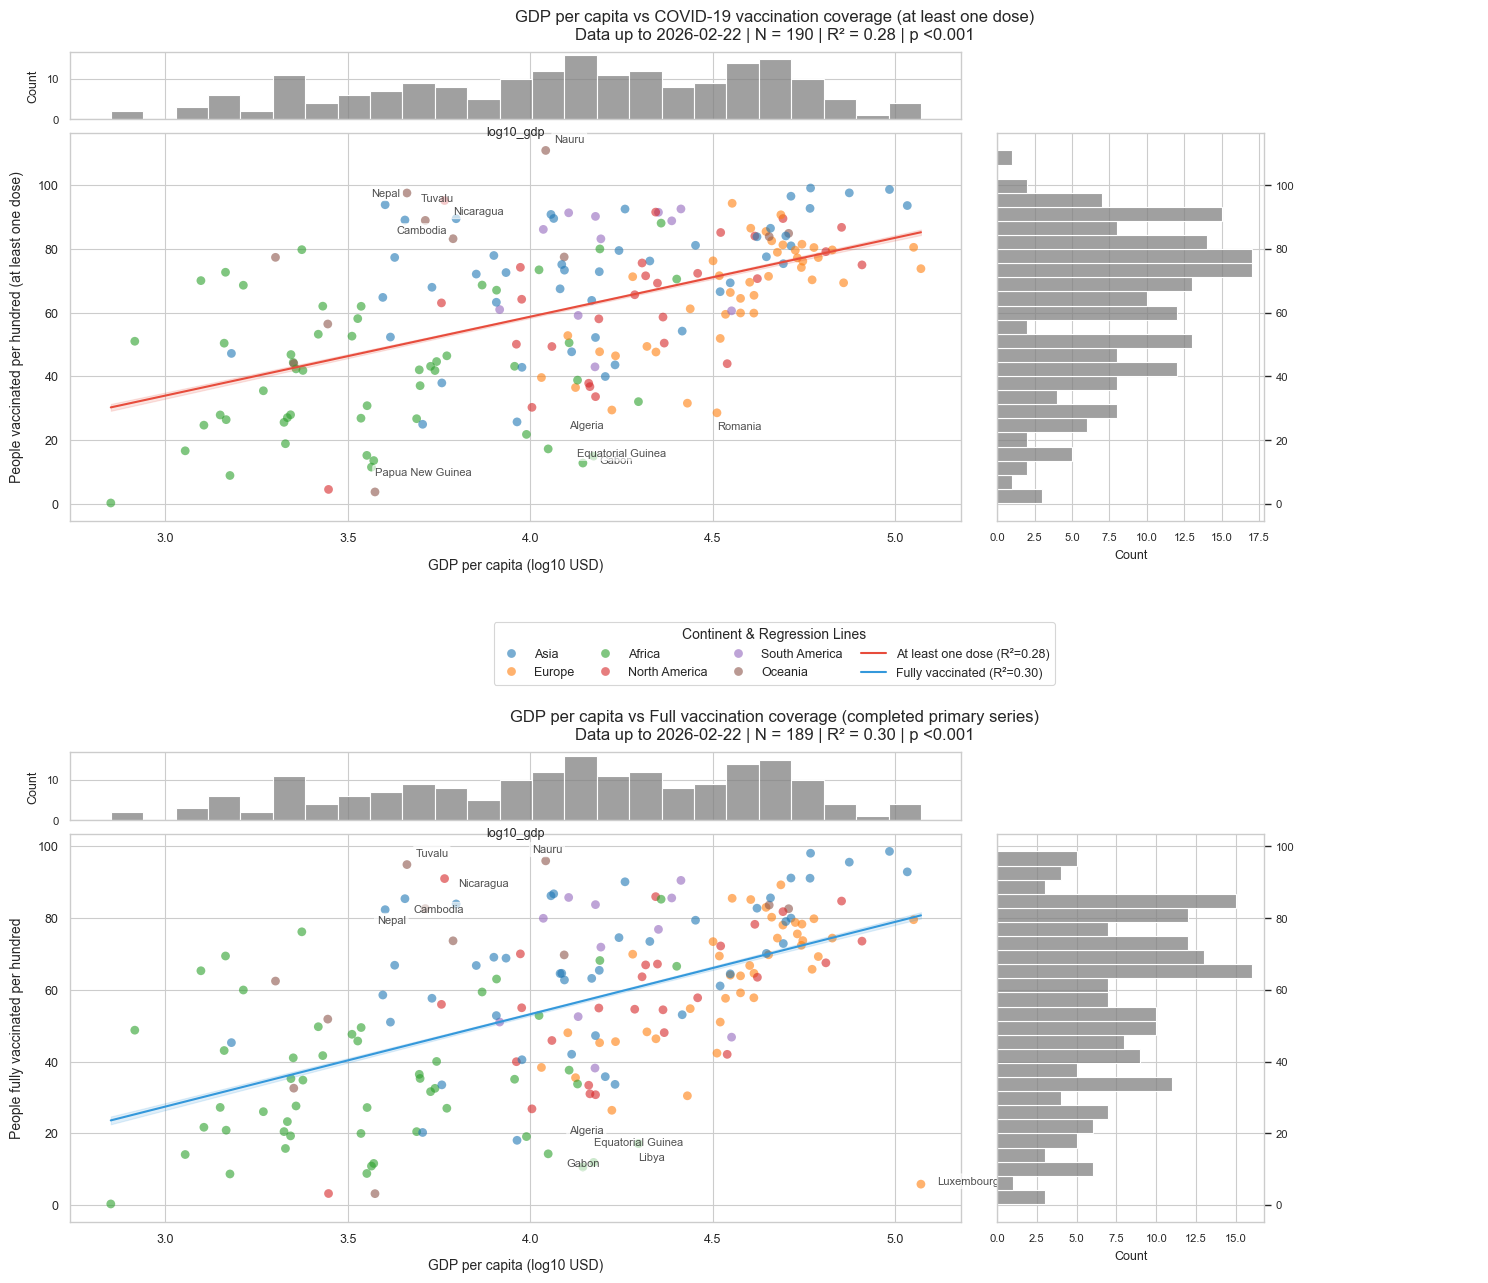

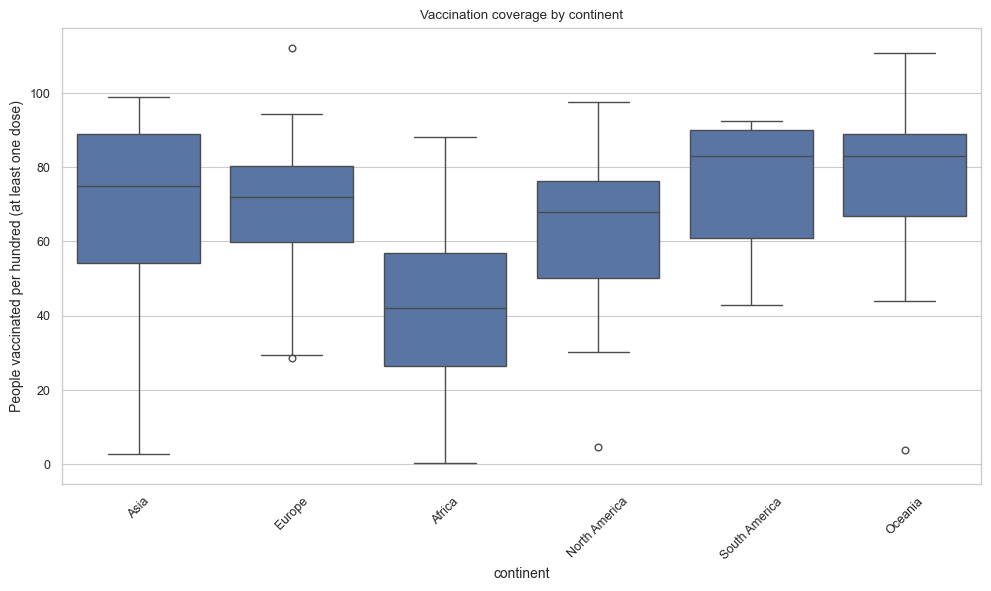

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Style settings
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# Load data
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = next((path for path in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents] if (path / "DataCleaning" / "compact_clean.csv").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find DataCleaning/compact_clean.csv from the current notebook location.")
data_path = PROJECT_ROOT / "DataCleaning" / "compact_clean.csv"
OUTPUT_DIR = PROJECT_ROOT / "Insights" / "Countries_vaccinationCoverage"
GDP_VACCINATION_IMAGE = OUTPUT_DIR / "gdp_vaccination_coverage.png"
CONTINENT_VACCINATION_IMAGE = OUTPUT_DIR / "vaccination_coverage_by_continent.png"

df = pd.read_csv(data_path)

if "continent" not in df.columns:
    df["continent"] = "Other"

# Take the latest data for each country
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").groupby("country", as_index=False).last()
    time_point = df["date"].max().strftime("%Y-%m-%d")
else:
    time_point = "final_data"

def plot_single_chart(gs_cell, data, y_col, y_label, reg_color="red"):

    plot_data = data[["country", "gdp_per_capita", y_col, "continent"]].dropna()
    plot_data = plot_data[plot_data["gdp_per_capita"] > 0]
    plot_data["log10_gdp"] = np.log10(plot_data["gdp_per_capita"])

    x = plot_data["log10_gdp"]
    y = plot_data[y_col]
    slope, intercept, r, p, std_err = stats.linregress(x, y)
    n = len(plot_data)

    gs_inner = gs_cell.subgridspec(3, 3,
                                   width_ratios=[4, 1.2, 0.8],
                                   height_ratios=[0.7, 4, 0.5],
                                   wspace=0.08, hspace=0.08)

    ax_main = fig.add_subplot(gs_inner[1, 0])
    ax_marg_x = fig.add_subplot(gs_inner[0, 0], sharex=ax_main)
    ax_marg_y = fig.add_subplot(gs_inner[1, 1], sharey=ax_main)
    ax_legend = fig.add_subplot(gs_inner[1, 2])
    ax_legend.axis('off')

    # Main scatter plot
    scatter = sns.scatterplot(data=plot_data, x="log10_gdp", y=y_col, hue="continent",
                              alpha=0.6, s=40, edgecolor="none", palette="tab10", ax=ax_main)

    # Regression line + confidence interval
    x_range = np.linspace(x.min(), x.max(), 100)
    y_pred = slope * x_range + intercept
    se = std_err * np.sqrt(1 / n + (x_range - x.mean()) ** 2 / np.sum((x - x.mean()) ** 2))
    ci = 1.96 * se
    reg_line, = ax_main.plot(x_range, y_pred, color=reg_color, lw=1.5)
    ax_main.fill_between(x_range, y_pred - ci, y_pred + ci, color=reg_color, alpha=0.15)

    ax_main.set_xlabel("GDP per capita (log10 USD)", fontsize=10, labelpad=10)
    ax_main.set_ylabel(y_label, fontsize=10, labelpad=10)

    if ax_main.get_legend():
        ax_main.get_legend().remove()

    # Marginal histograms
    sns.histplot(data=plot_data, x="log10_gdp", ax=ax_marg_x, bins=25, edgecolor="white", color="gray")
    sns.histplot(data=plot_data, y=y_col, ax=ax_marg_y, bins=25, edgecolor="white", color="gray")
    
    ax_marg_x.tick_params(labelbottom=False, labelsize=8)
    ax_marg_x.set_xlabel("log10_gdp", fontsize=9, labelpad=5)
    ax_marg_x.set_ylabel("Count", fontsize=9, labelpad=5)
    
    ax_marg_y.tick_params(labelleft=False, labelright=True, right=True, left=False, labelsize=8)
    ax_marg_y.set_ylabel("")
    ax_marg_y.set_xlabel("Count", fontsize=9, labelpad=5)

    plot_data["residual"] = y - (slope * x + intercept)
    outliers = pd.concat([plot_data.nlargest(5, "residual"), plot_data.nsmallest(5, "residual")])
    offsets = [(6, 6), (10, -6), (-10, 6), (6, -10), (-6, -10), (12, 0), (-12, 0), (0, 12), (0, -12), (15, 15)]
    for i, (idx, row) in enumerate(outliers.iterrows()):
        off = offsets[i % len(offsets)]
        ax_main.annotate(row["country"], (row["log10_gdp"], row[y_col]),
                         xytext=off, textcoords="offset points", fontsize=8, alpha=0.8,
                         bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6))

    return n, r**2, p, scatter.get_legend_handles_labels()[0], scatter.get_legend_handles_labels()[1], reg_line

fig = plt.figure(figsize=(16, 14))

gs_main = fig.add_gridspec(2, 1, hspace=0.32, top=0.94, bottom=0.06, left=0.06, right=0.94)

n1, r2_1, p1, handles1, labels1, reg_line1 = plot_single_chart(
    gs_main[0], df, "people_vaccinated_per_hundred",
    "People vaccinated per hundred (at least one dose)",
    reg_color="#e74c3c"  #red
)

n2, r2_2, p2, handles2, labels2, reg_line2 = plot_single_chart(
    gs_main[1], df, "people_fully_vaccinated_per_hundred",
    "People fully vaccinated per hundred",
    reg_color="#3498db"  #blue
)

# Title
fig.text(0.5, 0.97,
         "GDP per capita vs COVID-19 vaccination coverage (at least one dose)\n"
         f"Data up to {time_point} | N = {n1} | R² = {r2_1:.2f} | p {'<0.001' if p1 < 0.001 else f'={p1:.3f}'}",
         ha='center', va='top', fontsize=12)

fig.text(0.5, 0.47,
         "GDP per capita vs Full vaccination coverage (completed primary series)\n"
         f"Data up to {time_point} | N = {n2} | R² = {r2_2:.2f} | p {'<0.001' if p2 < 0.001 else f'={p2:.3f}'}",
         ha='center', va='top', fontsize=12)

handles = handles1 + [reg_line1, reg_line2]
labels = labels1 + [
    f"At least one dose (R²={r2_1:.2f})",
    f"Fully vaccinated (R²={r2_2:.2f})"
]

legend = fig.legend(handles, labels, title="Continent & Regression Lines", loc='center',
           bbox_to_anchor=(0.5, 0.51), ncol=4, frameon=True, fontsize=9,
           columnspacing=1.5, handletextpad=0.8)
legend.get_title().set_fontsize(10)
legend.get_title().set_ha('center')

fig.savefig(GDP_VACCINATION_IMAGE, dpi=300, bbox_inches="tight")
plt.show()

# Box
plt.figure(figsize=(10,6))
sns.boxplot(data=df.dropna(subset=["people_vaccinated_per_hundred", "continent"]),
            x="continent", y="people_vaccinated_per_hundred")
plt.xticks(rotation=45)
plt.ylabel("People vaccinated per hundred (at least one dose)")
plt.title("Vaccination coverage by continent")
plt.tight_layout()
plt.savefig(CONTINENT_VACCINATION_IMAGE, dpi=300, bbox_inches="tight")
plt.show()

# World Map
import plotly.express as px

map_data = df[["country", "code", "people_vaccinated_per_hundred", 
               "people_fully_vaccinated_per_hundred", "gdp_per_capita"]].dropna()

# 1 At least one
fig1 = px.choropleth(map_data, 
                     locations="code",
                     color="people_vaccinated_per_hundred",
                     hover_name="country",
                     color_continuous_scale="Viridis",
                     title="COVID-19 Vaccination Coverage (at least one dose) per hundred people",
                     labels={"people_vaccinated_per_hundred": "Vaccinated per 100"},
                     width=1200,
                     height=800)
fig1.show()

# 2 Fully
fig2 = px.choropleth(map_data,
                     locations="code",
                     color="people_fully_vaccinated_per_hundred",
                     hover_name="country",
                     color_continuous_scale="Plasma",
                     title="Full Vaccination Coverage (completed primary series) per hundred people",
                     labels={"people_fully_vaccinated_per_hundred": "Fully vaccinated per 100"},
                     width=1200,
                     height=800)
fig2.show()

# 3 GDP
fig3 = px.choropleth(map_data,
                     locations="code",
                     color="gdp_per_capita",
                     hover_name="country",
                     color_continuous_scale="Blues",
                     title="GDP per capita (USD)",
                     labels={"gdp_per_capita": "GDP per capita"},
                     width=1200,
                     height=800)
fig3.show()